In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Set random seed for consistent results
np.random.seed(101)
n_properties = 500
n_years = 1000

# --- PART A: GENERATE GULF COAST PROPERTIES ---
# Simulate 500 high-value commercial properties along the Gulf Coast (TX to FL)
prop_data = {
    'Property_ID': [f'PROP-{i:04d}' for i in range(1, n_properties + 1)],
    'Latitude': np.random.uniform(26.0, 30.0, n_properties),
    'Longitude': np.random.uniform(-97.0, -80.0, n_properties),
    'Building_Value_USD': np.random.lognormal(mean=15.5, sigma=0.6, size=n_properties).astype(int) # $2M to $15M+
}
properties_df = pd.DataFrame(prop_data)

# --- PART B: GENERATE STOCHASTIC HURRICANE EVENTS ---
# Simulate 1,000 years of weather. Not every year has a major storm; some have multiple.
years = np.repeat(np.arange(1, n_years + 1), 2) # Simulate up to 2 possible storms per year
n_events = len(years)

event_data = {
    'Sim_Year': years,
    'Event_ID': [f'EVT-{i:05d}' for i in range(1, n_events + 1)],
    # Random landfall coordinates along the Gulf Coast line
    'Landfall_Lat': np.random.uniform(26.0, 30.0, n_events),
    'Landfall_Lon': np.random.uniform(-97.0, -80.0, n_events),
    # Max wind speed at landfall in knots (Category 1 to Category 5 hurricanes)
    'Max_Wind_Knots': np.random.exponential(scale=30, size=n_events) + 64
}
events_df = pd.DataFrame(event_data)
# Keep only realistic hurricane-strength storms
events_df = events_df[events_df['Max_Wind_Knots'] <= 165].reset_index(drop=True)

print(f"Generated {len(properties_df)} commercial properties.")
print(f"Simulated {len(events_df)} stochastic hurricane events across {n_years} years.")


Generated 500 commercial properties.
Simulated 1934 stochastic hurricane events across 1000 years.


In [2]:
# Create an empty list to store our final matrix of losses
loss_records = []

print("Calculating losses per event... (this will take a few seconds)")

for _, event in events_df.iterrows():
    evt_id = event['Event_ID']
    evt_year = event['Sim_Year']
    e_lat, e_lon = event['Landfall_Lat'], event['Landfall_Lon']
    max_wind = event['Max_Wind_Knots']

    # Calculate approximate distance from storm landfall to all properties using simple Euclidean geometry
    distances = np.sqrt((properties_df['Latitude'] - e_lat)**2 + (properties_df['Longitude'] - e_lon)**2)

    # Wind decay formula: Wind drops off the further away a property is from the landfall center
    local_winds = max_wind * np.exp(-distances * 1.5)

    # Custom Vulnerability Curve: Map local wind speed to a Damage Ratio (0% to 100%)
    damage_ratios = np.zeros(len(local_winds))
    # No damage below 64 knots
    damage_ratios[local_winds > 64] = (local_winds[local_winds > 64] - 64) / (165 - 64)
    damage_ratios = np.clip(damage_ratios, 0, 1) # Ensure values stay between 0.0 and 1.0

    # Calculate dollar loss per property
    property_losses = damage_ratios * properties_df['Building_Value_USD']
    total_event_loss = property_losses.sum()

    # If the storm actually caused financial damage, record it
    if total_event_loss > 0:
        loss_records.append({'Year': evt_year, 'Event_ID': evt_id, 'Loss_USD': total_event_loss})

losses_df = pd.DataFrame(loss_records)
print(f"Loss matrix calculated! Total unique loss-producing events tracked: {len(losses_df)}")


Calculating losses per event... (this will take a few seconds)
Loss matrix calculated! Total unique loss-producing events tracked: 1013


📌 --- KEY PROBABILISTIC LOSS BENCHMARKS ---
10-Year Loss (1/10 probability): $8,295,314.39
20-Year Loss (1/20 probability): $12,021,226.06
50-Year Loss (1/50 probability): $16,252,414.49
100-Year Loss (1/100 probability): $18,456,068.74
250-Year Loss (1/250 probability): $25,345,254.88
500-Year Loss (1/500 probability): $27,674,582.82


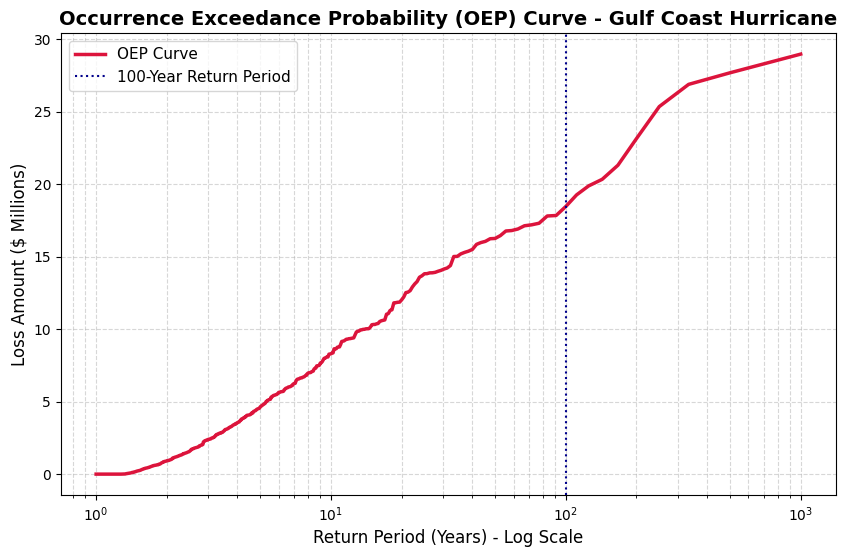

In [3]:
# 1. Aggregate losses by year to find the maximum loss experienced in each year (OEP)
annual_max = losses_df.groupby('Year')['Loss_USD'].max().reset_index()

# 2. Account for years that had zero hurricane losses by adding them back into our 1,000-year timeline
all_years = pd.DataFrame({'Year': np.arange(1, n_years + 1)})
annual_max = pd.merge(all_years, annual_max, on='Year', how='left').fillna(0)

# 3. Sort the annual maximum losses from highest to lowest
annual_max = annual_max.sort_values(by='Loss_USD', ascending=False).reset_index(drop=True)

# 4. Calculate Exceedance Probability and Return Period for each rank
annual_max['Rank'] = annual_max.index + 1
annual_max['Exceedance_Prob'] = annual_max['Rank'] / (n_years + 1)
annual_max['Return_Period'] = 1 / annual_max['Exceedance_Prob']

# 5. Extract core benchmark return period losses for insurance executives
return_periods = [10, 20, 50, 100, 250, 500]
print("📌 --- KEY PROBABILISTIC LOSS BENCHMARKS ---")
for rp in return_periods:
    # Find the loss amount closest to the target return period
    closest_idx = (annual_max['Return_Period'] - rp).abs().idxmin()
    loss_amount = annual_max.loc[closest_idx, 'Loss_USD']
    print(f"{rp}-Year Loss (1/{rp} probability): ${loss_amount:,.02f}")

# 6. Plot the Exceedance Probability (EP) Curve
plt.figure(figsize=(10, 6))
plt.plot(annual_max['Return_Period'], annual_max['Loss_USD'] / 1e6, color='crimson', lw=2.5, label='OEP Curve')
plt.xscale('log') # Industry standard uses a logarithmic x-axis for return periods
plt.title('Occurrence Exceedance Probability (OEP) Curve - Gulf Coast Hurricane', fontsize=14, fontweight='bold')
plt.xlabel('Return Period (Years) - Log Scale', fontsize=12)
plt.ylabel('Loss Amount ($ Millions)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.axvline(100, color='darkblue', linestyle=':', label='100-Year Return Period')
plt.legend(fontsize=11)
plt.show()
